In [1]:
# !pip install -q "transformers>=4.44" "datasets>=2.18" accelerate scikit-learn matplotlib seaborn
# Optional (for Section 7: PEFT/LoRA):
# !pip install -q peft
# Optional (for Section 6b: Friedman + Nemenyi):
# !pip install -q scikit-posthocs

import os, random, numpy as np, pandas as pd
import warnings

warnings.filterwarnings("ignore")

# Your proxy & env (from earlier)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")
os.environ["https_proxy"] = "http://10.101.159.162:7890"
os.environ["http_proxy"] = "http://10.101.159.162:7890"

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [2]:
# DATA
DATA_DIR = "../data"
RED_WINE_PATH = os.path.join(
    DATA_DIR, "WineQuality-RedWine.csv"
)  # red wine (binary good vs not_good)
GOOD_THRESHOLD = 7

# Prior ablation results (if available); update if you stored elsewhere
ABLATION_CSV = "runs/gpt2_prompt_tabular/ablation/ablation_results.csv"

# MODEL & TRAINING
MODEL_NAME = "gpt2"  # try "distilgpt2" if memory is tight
MAX_LENGTH = 256
BATCH_TRAIN = 16
BATCH_EVAL = 32
EPOCHS = 5
LR = 5e-5
WEIGHT_DECAY = 0.01

# MULTI-SEED
SEEDS = [42, 43, 44, 45, 46]

# OUTPUTS
RUN_ROOT = "runs/gpt2_prompt_tabular"
OUT_DIR = os.path.join(RUN_ROOT, "validation")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
OUT_DIR

'runs/gpt2_prompt_tabular\\validation'

In [3]:
import pandas as pd

df = pd.read_csv(RED_WINE_PATH)
assert "quality" in df.columns, "Expected 'quality' in WineQuality-RedWine.csv"

df["label"] = (df["quality"] >= GOOD_THRESHOLD).astype(int)  # 1 = good
feature_cols = [c for c in df.columns if c not in ["quality", "label"]]

id2label = {0: "not_good", 1: "good"}
label2id = {"not_good": 0, "good": 1}

print("Rows:", len(df))
print("Features:", feature_cols)
df.head(3)

Rows: 1599
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0


In [4]:
def serialize_row(row, cols, template="bullet"):
    pretty = {
        "fixed acidity": ("fixed acidity", "g/dm^3"),
        "volatile acidity": ("volatile acidity", "g/dm^3"),
        "citric acid": ("citric acid", "g/dm^3"),
        "residual sugar": ("residual sugar", "g/dm^3"),
        "chlorides": ("chlorides", "g/dm^3"),
        "free sulfur dioxide": ("free sulfur dioxide", "mg/dm^3"),
        "total sulfur dioxide": ("total sulfur dioxide", "mg/dm^3"),
        "density": ("density", "g/cm^3"),
        "pH": ("pH", ""),
        "sulphates": ("sulphates", "g/dm^3"),
        "alcohol": ("alcohol", "% vol"),
    }

    def nm(c):
        return pretty.get(c, (c, ""))[0]

    def un(c):
        return pretty.get(c, (c, ""))[1]

    if template == "bullet":
        lines = ["The following red wine has these lab measurements:"]
        for c in cols:
            lines.append(f"- {nm(c)}: {row[c]} {un(c)}".rstrip())
        lines += [
            "",
            "Question: Is this wine high quality (good) or not good?",
            "Answer:",
        ]
        return "\n".join(lines)
    else:
        parts = []
        for c in cols:
            u = un(c)
            parts.append(f"{nm(c)} {row[c]}{(' ' + u) if u else ''}".strip())
        body = ", ".join(parts[:-1]) + (", and " + parts[-1] if parts else "")
        return f"Given a red wine with {body}. Is this wine high quality (good) or not good? Answer:"


from sklearn.model_selection import train_test_split

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
X_train, X_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
X_train, X_val = train_test_split(
    X_train, test_size=0.2, random_state=SEED, stratify=X_train["label"]
)

for name, split in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(
        name,
        split.shape,
        split["label"].value_counts(normalize=True).round(3).to_dict(),
    )

train (1023, 13) {0: 0.864, 1: 0.136}
val (256, 13) {0: 0.863, 1: 0.137}
test (320, 13) {0: 0.866, 1: 0.134}


In [5]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np


def select_topk_features(X_df, y_series, all_features, top_k=None):
    if (top_k is None) or (top_k >= len(all_features)):
        return list(all_features)
    X = X_df[all_features].values
    mi = mutual_info_classif(X, y_series, random_state=SEED)
    order = np.argsort(mi)[::-1]
    return [all_features[i] for i in order[:top_k]]


# Precompute several values we might use
FS_CACHE = {}
for k in [3, 5, 7, 9]:
    FS_CACHE[k] = select_topk_features(X_train, X_train["label"], feature_cols, k)
FS_CACHE

{3: ['alcohol', 'sulphates', 'volatile acidity'],
 5: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid'],
 7: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid',
  'density',
  'chlorides'],
 9: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid',
  'density',
  'chlorides',
  'total sulfur dioxide',
  'residual sugar']}

In [6]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_text(df_in, cols, template):
    return df_in.apply(lambda r: serialize_row(r, cols, template), axis=1)


def to_hf(split_df):
    return Dataset.from_pandas(split_df[["text", "label"]].reset_index(drop=True))


def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


def make_tok_ds(train_df, val_df, test_df):
    raw = DatasetDict(
        {
            "train": to_hf(train_df),
            "validation": to_hf(val_df),
            "test": to_hf(test_df),
        }
    )
    tok = raw.map(tokenize_fn, batched=True, remove_columns=["text"])
    return tok

In [7]:
from transformers import GPT2ForSequenceClassification, TrainingArguments, Trainer
from transformers import DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, classification_report

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def run_one(seed, template="bullet", top_k=None, epochs=EPOCHS, lr=LR):
    # pick feature subset
    if top_k is None:
        cols = list(feature_cols)
    else:
        if top_k not in FS_CACHE:
            FS_CACHE[top_k] = select_topk_features(
                X_train, X_train["label"], feature_cols, top_k
            )
        cols = FS_CACHE[top_k]

    # build prompts
    tr, va, te = X_train.copy(), X_val.copy(), X_test.copy()
    tr["text"] = build_text(tr, cols, template)
    va["text"] = build_text(va, cols, template)
    te["text"] = build_text(te, cols, template)

    # tokenize
    tok_ds = make_tok_ds(tr, va, te)

    # model
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    # metrics
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    out_dir = os.path.join(
        OUT_DIR, f"seed{seed}_{template}_topk{top_k if top_k is not None else 'all'}"
    )
    args = TrainingArguments(
        output_dir=out_dir,
        logging_dir=os.path.join(out_dir, "logs"),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=lr,
        num_train_epochs=epochs,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=seed,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()

    # test
    pred = trainer.predict(tok_ds["test"])
    y_true = pred.label_ids
    y_pred = pred.predictions.argmax(-1)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    # save classification report
    rep_df = pd.DataFrame(
        classification_report(
            y_true, y_pred, target_names=["not_good", "good"], output_dict=True
        )
    ).T
    rep_df.to_csv(os.path.join(out_dir, "test_classification_report.csv"))

    return {
        "seed": seed,
        "template": template,
        "top_k": (top_k if top_k is not None else "all"),
        "features_used": cols,
        "test_accuracy": acc,
        "test_f1_macro": f1,
        "run_dir": out_dir,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [8]:
# Try to read your ablation CSV and pick the two best (template, top_k)
if os.path.exists(ABLATION_CSV):
    ab = pd.read_csv(ABLATION_CSV)
    # normalize
    ab["top_k"] = ab["top_k"].apply(
        lambda x: (
            None
            if str(x).lower() in {"none", "all"}
            else (int(x) if not pd.isna(x) else None)
        )
    )
    top2 = (
        ab.groupby(["template", "top_k"])
        .agg(f1_mean=("test_f1_macro", "mean"))
        .reset_index()
        .sort_values("f1_mean", ascending=False)
        .head(2)
    )
    CANDIDATES = [
        {
            "name": f"C{i+1}",
            "template": r.template,
            "top_k": (None if pd.isna(r.top_k) else r.top_k),
        }
        for i, r in top2.iterrows()
    ]
else:
    # Fallback: try bullet/top_k=5 vs inline/all
    CANDIDATES = [
        {"name": "C1", "template": "bullet", "top_k": 5},
        {"name": "C2", "template": "inline", "top_k": None},
    ]

CANDIDATES

[{'name': 'C5', 'template': 'inline', 'top_k': 7},
 {'name': 'C2', 'template': 'bullet', 'top_k': 7}]

In [9]:
rows = []
per_seed = {}  # keep per-config vectors for stats
for cand in CANDIDATES:
    f1s, accs = [], []
    for s in SEEDS:
        r = run_one(seed=s, template=cand["template"], top_k=cand["top_k"])
        f1s.append(r["test_f1_macro"])
        accs.append(r["test_accuracy"])
    per_seed[cand["name"]] = {"f1s": f1s, "accs": accs}
    rows.append(
        {
            "config": cand["name"],
            "template": cand["template"],
            "top_k": cand["top_k"] if cand["top_k"] is not None else "all",
            "f1_mean": np.mean(f1s),
            "f1_std": np.std(f1s),
            "acc_mean": np.mean(accs),
            "acc_std": np.std(accs),
            "runs": len(SEEDS),
        }
    )

multi_seed_summary = pd.DataFrame(rows).sort_values("f1_mean", ascending=False)
multi_seed_path = os.path.join(OUT_DIR, "multi_seed_summary.csv")
multi_seed_summary.to_csv(multi_seed_path, index=False)
multi_seed_summary

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

{'eval_loss': 0.330196738243103, 'eval_accuracy': 0.8671875, 'eval_f1_macro': 0.6361204013377927, 'eval_runtime': 6.8576, 'eval_samples_per_second': 37.331, 'eval_steps_per_second': 1.167, 'epoch': 4.0}


  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.34299683570861816, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 6.6583, 'eval_samples_per_second': 38.448, 'eval_steps_per_second': 1.202, 'epoch': 5.0}
{'train_runtime': 470.1505, 'train_samples_per_second': 10.879, 'train_steps_per_second': 0.681, 'train_loss': 0.3880345344543457, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

,config,template,top_k,f1_mean,f1_std,acc_mean,acc_std,runs
0,C5,inline,7,0.649381,0.092977,0.87625,0.005449,5
1,C2,bullet,7,0.590456,0.103684,0.85000,0.042482,5


In [10]:
# Wilcoxon signed-rank test for the top two configs (paired by seed)
# Demšar (2006) recommends Wilcoxon for pairwise nonparametric comparisons.
from scipy.stats import wilcoxon

names = [c["name"] for c in CANDIDATES]
f1s_A = per_seed[names[0]]["f1s"]
f1s_B = per_seed[names[1]]["f1s"]
stat, p = wilcoxon(f1s_A, f1s_B, zero_method="wilcox", alternative="two-sided")
print(f"Wilcoxon signed-rank (F1): stat={stat}, p={p:.4g}")

Wilcoxon signed-rank (F1): stat=0.0, p=0.06789


In [11]:
# Re-run best config on a single seed to collect predictions for slicing
best = multi_seed_summary.iloc[0]
best_template = best["template"]
best_topk = None if best["top_k"] == "all" else int(best["top_k"])

out = run_one(seed=SEED, template=best_template, top_k=best_topk)
y_true, y_pred = np.array(out["y_true"]), np.array(out["y_pred"])

Xtest = X_test.copy()
Xtest["y_true"] = y_true
Xtest["y_pred"] = y_pred
errs = Xtest[Xtest.y_true != Xtest.y_pred]
print("Test errors:", len(errs), "out of", len(Xtest))

# Quick look at feature distributions in errors
errs.describe()

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.3476780951023102, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 5.2645, 'eval_samples_per_second': 48.628, 'eval_steps_per_second': 1.52, 'epoch': 5.0}
{'train_runtime': 417.5481, 'train_samples_per_second': 12.25, 'train_steps_per_second': 0.766, 'train_loss': 0.391320538520813, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

Test errors: 39 out of 320


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label,y_true,y_pred
count,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000,39.000000
mean,8.215385,0.422821,0.326410,2.406410,0.071897,16.179487,37.358974,0.995318,3.344359,0.688205,11.689744,6.769231,0.692308,0.692308,0.307692
std,2.113558,0.146021,0.205573,1.046119,0.020443,11.550511,25.232067,0.002369,0.224743,0.132543,1.036135,0.667341,0.467572,0.467572,0.467572
min,5.000000,0.180000,0.000000,0.900000,0.012000,4.000000,8.000000,0.990070,2.890000,0.390000,9.900000,5.000000,0.000000,0.000000,0.000000
25%,6.550000,0.305000,0.175000,1.900000,0.060000,7.000000,18.500000,0.994260,3.215000,0.605000,11.000000,6.000000,0.000000,0.000000,0.000000
50%,7.600000,0.400000,0.340000,2.100000,0.074000,13.000000,28.000000,0.995380,3.350000,0.670000,11.700000,7.000000,1.000000,1.000000,0.000000
75%,9.750000,0.540000,0.465000,2.600000,0.080000,18.500000,46.500000,0.996580,3.430000,0.755000,12.500000,7.000000,1.000000,1.000000,1.000000
max,12.800000,0.750000,0.740000,6.000000,0.121000,45.000000,109.000000,1.002200,4.010000,1.040000,14.000000,8.000000,1.000000,1.000000,1.000000


In [12]:
# Using validation logits to choose a probability threshold, apply to test
from sklearn.metrics import f1_score

# Rebuild a trainer to access validation logits for the best config
_ = run_one  # function already defined; we will rebuild the trainer steps here briefly
# Build prompts for val/test
cols = FS_CACHE[best_topk] if best_topk is not None else list(feature_cols)
tr, va, te = X_train.copy(), X_val.copy(), X_test.copy()
tr["text"] = build_text(tr, cols, best_template)
va["text"] = build_text(va, cols, best_template)
te["text"] = build_text(te, cols, best_template)
tok_ds = make_tok_ds(tr, va, te)

from transformers import GPT2ForSequenceClassification, TrainingArguments, Trainer

model = GPT2ForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    pad_token_id=tokenizer.pad_token_id,
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)


def cm(ep):
    logits, labels = ep
    preds = logits.argmax(-1)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro")),
    }


args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "threshold_probe"),
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=BATCH_TRAIN,
    per_device_eval_batch_size=BATCH_EVAL,
    learning_rate=LR,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=cm,
)
trainer.train()

val_logits = trainer.predict(tok_ds["validation"]).predictions
# convert to probability of class 1 (softmax)
p1_val = np.exp(val_logits[:, 1]) / np.exp(val_logits).sum(axis=1)
val_labels = np.array(tok_ds["validation"]["label"])

best_t, best_f1 = 0.5, -1
for t in np.linspace(0.3, 0.7, 41):
    f1 = f1_score(val_labels, (p1_val >= t).astype(int), average="macro")
    if f1 > best_f1:
        best_f1, best_t = f1, t
print("Best threshold on val:", round(best_t, 3), "Val F1:", round(best_f1, 4))

test_logits = trainer.predict(tok_ds["test"]).predictions
p1_test = np.exp(test_logits[:, 1]) / np.exp(test_logits).sum(axis=1)
f1_test_thresh = f1_score(
    np.array(tok_ds["test"]["label"]), (p1_test >= best_t).astype(int), average="macro"
)
print("Thresholded Test F1:", round(f1_test_thresh, 4))

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

{'eval_loss': 0.33397579193115234, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 6.877, 'eval_samples_per_second': 37.225, 'eval_steps_per_second': 1.163, 'epoch': 5.0}
{'train_runtime': 306.3955, 'train_samples_per_second': 16.694, 'train_steps_per_second': 1.044, 'train_loss': 0.4314900875091553, 'epoch': 5.0}


  0%|          | 0/8 [00:00<?, ?it/s]

Best threshold on val: 0.3 Val F1: 0.6435


  0%|          | 0/10 [00:00<?, ?it/s]

Thresholded Test F1: 0.7027


In [13]:
USE_LORA = True
try:
    from peft import LoraConfig, get_peft_model
except Exception as e:
    print("PEFT not installed; set USE_LORA=False or: pip install peft")
    USE_LORA = False

if USE_LORA:
    base = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    lora_cfg = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["c_attn", "c_proj"],
    )
    lora_model = get_peft_model(base, lora_cfg)
    lora_model.print_trainable_parameters()

    out_dir = os.path.join(OUT_DIR, "lora_best")
    args = TrainingArguments(
        output_dir=out_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    )

    def _cm(ep):
        logits, labels = ep
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    tr, va, te = X_train.copy(), X_val.copy(), X_test.copy()
    tr["text"] = build_text(tr, cols, best_template)
    va["text"] = build_text(va, cols, best_template)
    te["text"] = build_text(te, cols, best_template)
    tok_ds = make_tok_ds(tr, va, te)

    trainer = Trainer(
        model=lora_model,
        args=args,
        train_dataset=tok_ds["train"],
        eval_dataset=tok_ds["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=_cm,
    )
    trainer.train()
    pred = trainer.predict(tok_ds["test"])
    f1_lora = f1_score(pred.label_ids, pred.predictions.argmax(-1), average="macro")
    print("LoRA Test F1:", round(f1_lora, 4))

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 812,544 || all params: 125,253,888 || trainable%: 0.6487


Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

...

{'eval_loss': 0.6394841074943542, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 5.1679, 'eval_samples_per_second': 49.536, 'eval_steps_per_second': 1.548, 'epoch': 4.0}


  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.6584302186965942, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 5.1762, 'eval_samples_per_second': 49.457, 'eval_steps_per_second': 1.546, 'epoch': 5.0}
{'train_runtime': 251.7834, 'train_samples_per_second': 20.315, 'train_steps_per_second': 1.271, 'train_loss': 1.5115168571472168, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

LoRA Test F1: 0.464


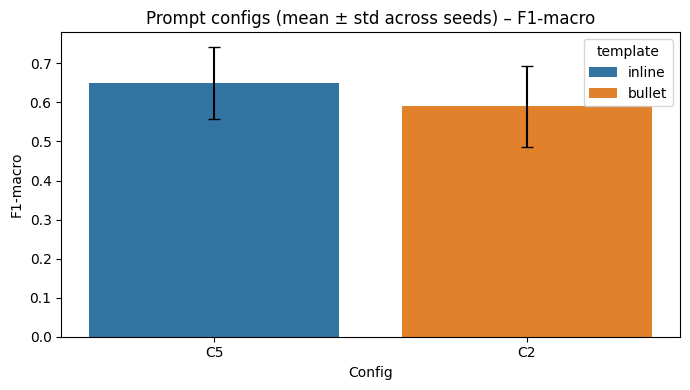

Saved: runs/gpt2_prompt_tabular\validation\multi_seed_summary.csv
Saved: runs/gpt2_prompt_tabular\validation\figures\prompt_configs_f1_bar.png


In [14]:
import json, matplotlib.pyplot as plt, seaborn as sns

# 1) Save multi-seed summary (already saved); show bar with error bars
ms = multi_seed_summary.copy()
plt.figure(figsize=(7, 4))
sns.barplot(data=ms, x="config", y="f1_mean", hue="template", errorbar=None)
for i, r in ms.iterrows():
    plt.errorbar(
        i, r["f1_mean"], yerr=r["f1_std"], fmt="none", capsize=4, color="black"
    )
plt.title("Prompt configs (mean ± std across seeds) – F1-macro")
plt.ylabel("F1-macro")
plt.xlabel("Config")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "prompt_configs_f1_bar.png"), dpi=150)
plt.show()

# 2) Save thresholded F1 (if computed)
summary_extra = {"best_template": best_template, "best_topk": best_topk}
try:
    summary_extra["thresholded_test_f1"] = float(f1_test_thresh)
except:
    pass

with open(os.path.join(OUT_DIR, "summary_extra.json"), "w") as f:
    json.dump(summary_extra, f, indent=2)

print("Saved:", os.path.join(OUT_DIR, "multi_seed_summary.csv"))
print("Saved:", os.path.join(FIG_DIR, "prompt_configs_f1_bar.png"))

In [15]:
# Requires: pip install scikit-posthocs
# Arrange results as matrix: rows = seeds, cols = methods (F1 values)
try:
    import scikit_posthocs as sp

    # Example scaffold (replace vectors with your real per-seed arrays):
    # M = np.column_stack([per_seed["C1"]["f1s"], per_seed["C2"]["f1s"], per_seed["C3"]["f1s"]])
    # friedman_pvals = sp.posthoc_nemenyi_friedman(M)
    # print(friedman_pvals)
    print("Friedman+Nemenyi scaffold ready. Fill M with your per-seed F1 columns.")
except Exception as e:
    print("Install scikit-posthocs to run Friedman+Nemenyi:", e)

Install scikit-posthocs to run Friedman+Nemenyi: No module named 'scikit_posthocs'
